# Data Visualisation — Dataset nettoyé

Analyse exploratoire du jeu de données **original parsé** : `data/transform/champignons_clean.csv`.

Objectif : repérer avant entraînement les valeurs aberrantes sur les tailles, visualiser les distributions catégorielles (couleurs, saisons, habitats) et mesurer le déséquilibre de la cible (nom / statut).

## 1. Chargement

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

CLEAN_CSV = "../../data/transform/champignons_clean.csv"
df = pd.read_csv(CLEAN_CSV)
print(f"{len(df)} espèces, {len(df.columns)} colonnes")
df.head(2)

217 espèces, 174 colonnes


,nom,statut,chapeau,pores,lames,pied,chair,odeur,saveur,habitat,...,habitat_type_jardins,habitat_type_bois,habitat_type_chenes,habitat_type_hetres,habitat_type_pins,habitat_type_bouleaux,habitat_type_chataigniers,habitat_type_charmes,habitat_type_melezes,habitat_type_bois_morts
0,AGARIC AUGUSTE,Champignon à rejeter,"5 à 25 cm, couvert de mèches brun-roux sur fon...",NaN,"Libres, crème puis gris-rose et enfin brunes.","Blanc, élancé (6 à 20 cm), légèrement en massu...","Blanche, jaunissant lentement à la coupe, rosé...","Agréable, d’amande amère",Douce,"Bois clairs de feuillus ou de conifères, lisiè...",...,0,1,0,0,0,0,0,0,0,0
1,AGARIC DES JACHÈRES,Les excellents champignons,"5 à 15 cm, lisse, blanc puis jaunissant en vie...",NaN,"Libres, serrées, gris-rose très pâle puis brun...","5 à 15 cm, élancé, avec un large anneau blanc ...","Blanche, ferme",Anisée,Douce,"Surtout sous feuillus, clairières, lisières, p...",...,0,0,0,0,0,0,0,0,0,0


## 2. Analyse des caractéristiques numériques (tailles)

Les tailles sont stockées comme intervalles `[min, max]` pour le chapeau et le pied. On calcule une **taille moyenne** par espèce (`(min + max) / 2`) et on trace distribution + boxplot pour repérer les valeurs aberrantes (un champignon de 200 cm n'existe pas, par exemple).

In [13]:
df["chapeau_taille"] = (df["chapeau_taille_min_cm"] + df["chapeau_taille_max_cm"]) / 2
df["pied_taille"]    = (df["pied_taille_min_cm"]    + df["pied_taille_max_cm"])    / 2

df[["chapeau_taille_min_cm", "chapeau_taille_max_cm", "pied_taille_min_cm", "pied_taille_max_cm", "chapeau_taille", "pied_taille"]].describe()

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\1416453938.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["chapeau_taille"] = (df["chapeau_taille_min_cm"] + df["chapeau_taille_max_cm"]) / 2
C:\Users\benja\AppData\Local\Temp\ipykernel_16572\1416453938.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["pied_taille"]    = (df["pied_taille_min_cm"]    + df["pied_taille_max_cm"])    / 2


,chapeau_taille_min_cm,chapeau_taille_max_cm,pied_taille_min_cm,pied_taille_max_cm,chapeau_taille,pied_taille
count,217.000000,217.000000,217.00000,217.000000,217.000000,217.000000
mean,2.972811,11.624424,3.18894,9.700461,7.298618,6.444700
std,2.550735,7.762278,1.93021,5.832353,4.832263,3.754295
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,2.000000,7.000000,2.00000,7.000000,4.500000,4.500000
50%,3.000000,10.000000,3.00000,10.000000,6.500000,6.500000
75%,4.000000,15.000000,5.00000,12.000000,9.500000,8.500000
max,30.000000,60.000000,10.00000,30.000000,37.500000,17.500000


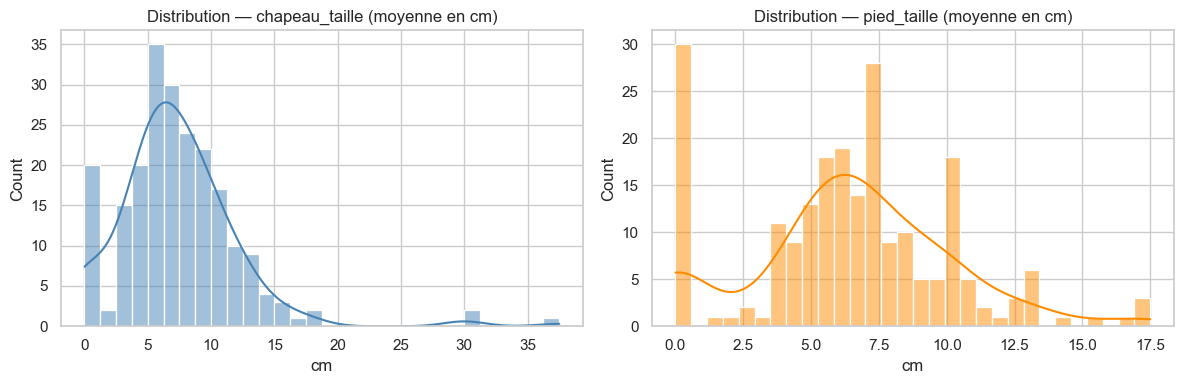

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["chapeau_taille"].dropna(), bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution — chapeau_taille (moyenne en cm)")
axes[0].set_xlabel("cm")

sns.histplot(df["pied_taille"].dropna(), bins=30, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution — pied_taille (moyenne en cm)")
axes[1].set_xlabel("cm")

plt.tight_layout()
plt.show()

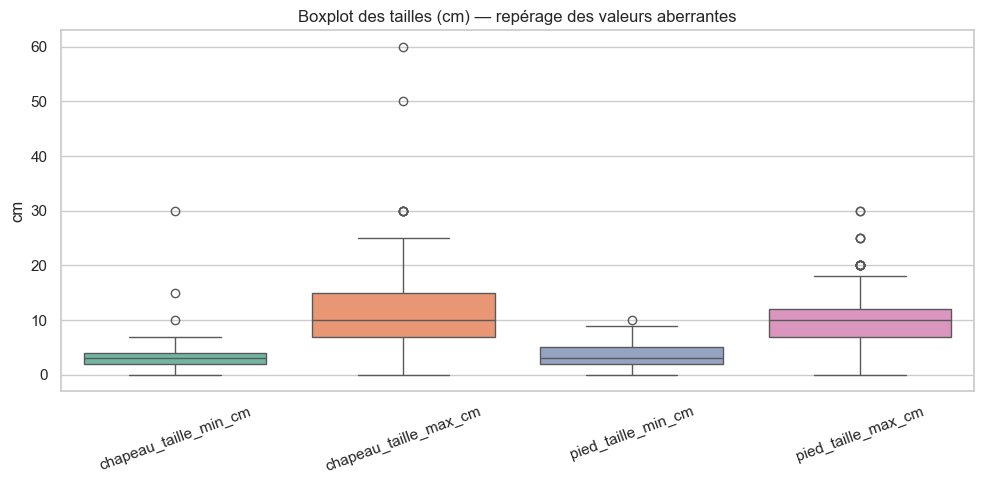

In [15]:
size_cols = ["chapeau_taille_min_cm", "chapeau_taille_max_cm", "pied_taille_min_cm", "pied_taille_max_cm"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[size_cols], ax=ax, palette="Set2")
ax.set_title("Boxplot des tailles (cm) — repérage des valeurs aberrantes")
ax.set_ylabel("cm")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [16]:
# Top 10 des espèces avec le plus grand chapeau — vérification d'aberrations
top_big = df.nlargest(10, "chapeau_taille_max_cm")[["nom", "chapeau_taille_min_cm", "chapeau_taille_max_cm"]]
print("Top 10 chapeaux les plus grands :")
top_big

Top 10 chapeaux les plus grands :


,nom,chapeau_taille_min_cm,chapeau_taille_max_cm
176,POLYPORE SOUFRÉ,15.0,60.0
174,POLYPORE ÉCAILLEUX,10.0,50.0
8,AMANITE OVOÏDE,6.0,30.0
39,BOLET SATAN,30.0,30.0
137,LACTAIRE VELOUTÉ,5.0,30.0
154,PAXILLE À PIED NOIR,4.0,30.0
170,PLEUROTE EN FORME D’HUÎTRE,2.0,30.0
0,AGARIC AUGUSTE,5.0,25.0
42,CÈPE BRONZÉ,4.0,25.0
44,CÈPE DE BORDEAUX,4.0,25.0


## 3. Analyse des caractéristiques catégorielles

### 3.1 Présence des attributs (binaires)

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\4138567339.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")


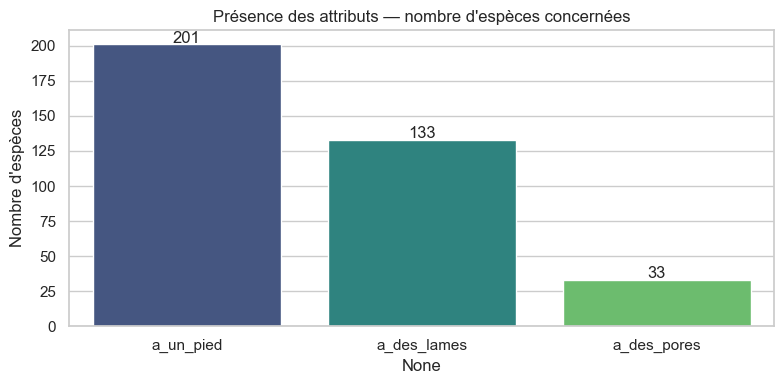

In [17]:
binary_presence = ["a_un_pied", "a_des_pores", "a_des_lames"]
counts = df[binary_presence].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
ax.set_title("Présence des attributs — nombre d'espèces concernées")
ax.set_ylabel("Nombre d'espèces")
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, f"{int(v)}", ha="center")
plt.tight_layout()
plt.show()

### 3.2 Top 10 des couleurs — chapeau et chair

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\3551752644.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chapeau_top.values, y=chapeau_top.index, ax=axes[0], palette="YlOrBr")
C:\Users\benja\AppData\Local\Temp\ipykernel_16572\3551752644.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chair_top.values, y=chair_top.index, ax=axes[1], palette="PuRd")


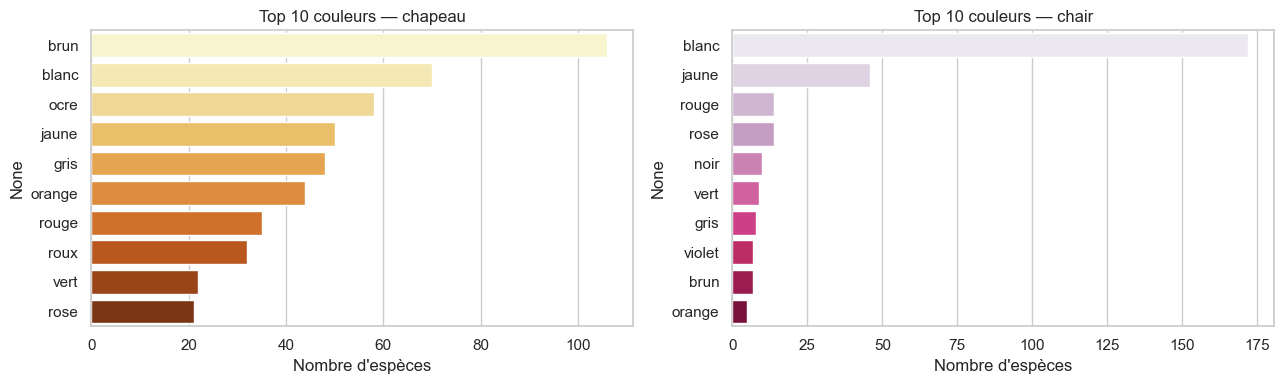

In [18]:
def top_k_by_prefix(df, prefix, k=10):
    cols = [c for c in df.columns if c.startswith(prefix)]
    counts = df[cols].sum().sort_values(ascending=False).head(k)
    counts.index = [c.replace(prefix, "") for c in counts.index]
    return counts

chapeau_top = top_k_by_prefix(df, "chapeau_couleur_", k=10)
chair_top   = top_k_by_prefix(df, "chair_couleur_",   k=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=chapeau_top.values, y=chapeau_top.index, ax=axes[0], palette="YlOrBr")
axes[0].set_title("Top 10 couleurs — chapeau")
axes[0].set_xlabel("Nombre d'espèces")

sns.barplot(x=chair_top.values, y=chair_top.index, ax=axes[1], palette="PuRd")
axes[1].set_title("Top 10 couleurs — chair")
axes[1].set_xlabel("Nombre d'espèces")

plt.tight_layout()
plt.show()

### 3.3 Saisons (mois d'apparition)

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\3743096551.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mois_labels, y=season_counts.values, ax=ax, palette="crest")


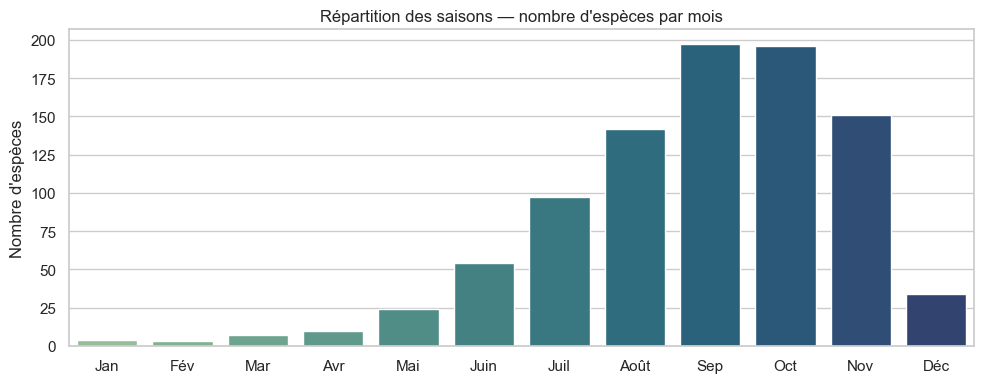

In [19]:
season_cols = [f"saison_mois_{i:02d}" for i in range(1, 13)]
season_counts = df[season_cols].sum()
mois_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=mois_labels, y=season_counts.values, ax=ax, palette="crest")
ax.set_title("Répartition des saisons — nombre d'espèces par mois")
ax.set_ylabel("Nombre d'espèces")
plt.tight_layout()
plt.show()

### 3.4 Habitats

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\3739914004.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=habitat_counts.values, y=habitat_counts.index, ax=ax, palette="mako")


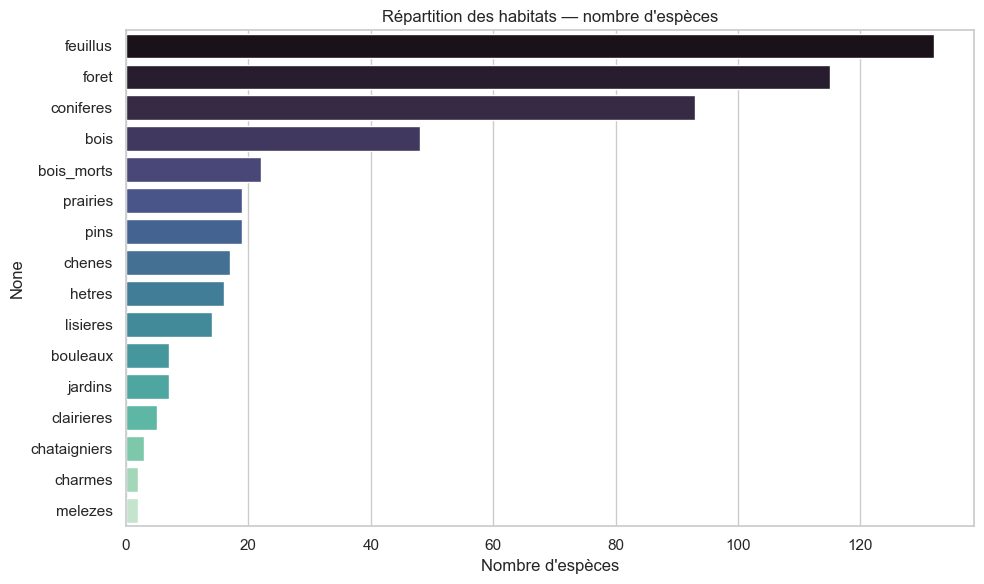

In [20]:
habitat_counts = top_k_by_prefix(df, "habitat_type_", k=16)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=habitat_counts.values, y=habitat_counts.index, ax=ax, palette="mako")
ax.set_title("Répartition des habitats — nombre d'espèces")
ax.set_xlabel("Nombre d'espèces")
plt.tight_layout()
plt.show()

## 4. Analyse de la cible

### 4.1 Cible = `nom` (classification par espèce)

Chaque espèce n'apparaît qu'une seule fois dans le dataset nettoyé : le déséquilibre intra-nom est nul, mais **le nombre de classes est très élevé** (≈ 217). C'est ce qui motive l'augmentation.

Nombre d'espèces distinctes : 217
Lignes par espèce — min : 1, max : 1, moyenne : 1.00


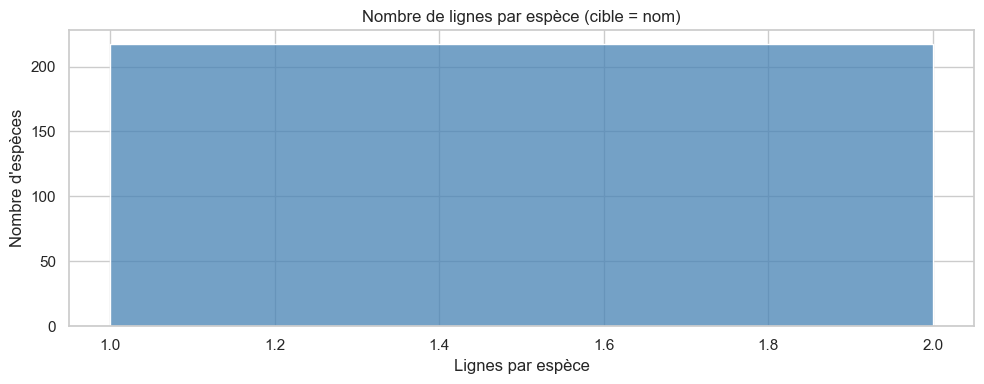

In [21]:
nom_counts = df["nom"].value_counts()
print(f"Nombre d'espèces distinctes : {nom_counts.shape[0]}")
print(f"Lignes par espèce — min : {nom_counts.min()}, max : {nom_counts.max()}, moyenne : {nom_counts.mean():.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(nom_counts.values, bins=range(1, nom_counts.max() + 2), ax=ax, color="steelblue")
ax.set_title("Nombre de lignes par espèce (cible = nom)")
ax.set_xlabel("Lignes par espèce")
ax.set_ylabel("Nombre d'espèces")
plt.tight_layout()
plt.show()

### 4.2 Cible = `statut` (comestible / toxique / ...)

statut
Champignon à rejeter          73
Les bons champignons          50
Les champignons toxiques      34
Les champignons mediocres     33
Les excellents champignons    18
Les champignons mortel         9
Name: count, dtype: int64


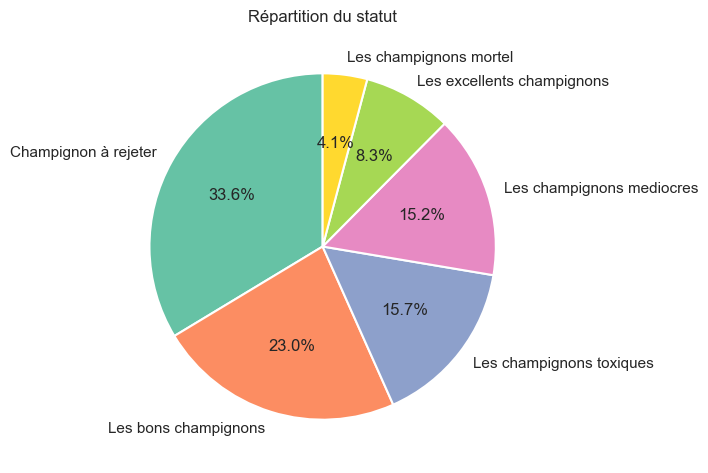

In [22]:
statut_counts = df["statut"].value_counts()
print(statut_counts)

fig, ax = plt.subplots(figsize=(7, 7))
colors = sns.color_palette("Set2", n_colors=len(statut_counts))
ax.pie(
    statut_counts.values,
    labels=statut_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Répartition du statut")
plt.tight_layout()
plt.show()

## 5. Corrélations entre `statut` et les autres features

La cible `nom` est volontairement exclue : ici on cherche ce qui **distingue statistiquement** les différents statuts (comestibles / toxiques / à rejeter / mortels…).

Trois angles :
1. Tailles numériques → boxplots groupés.
2. Features binaires → heatmap des proportions par statut (features les plus discriminantes).
3. Corrélation one-vs-rest (point-biserial) entre chaque classe de statut et chaque feature — top positives & négatives par classe.

### 5.1 Tailles numériques par statut

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\174948166.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="statut", y="chapeau_taille", order=order, ax=axes[0], palette="Set2")
C:\Users\benja\AppData\Local\Temp\ipykernel_16572\174948166.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="statut", y="pied_taille", order=order, ax=axes[1], palette="Set2")


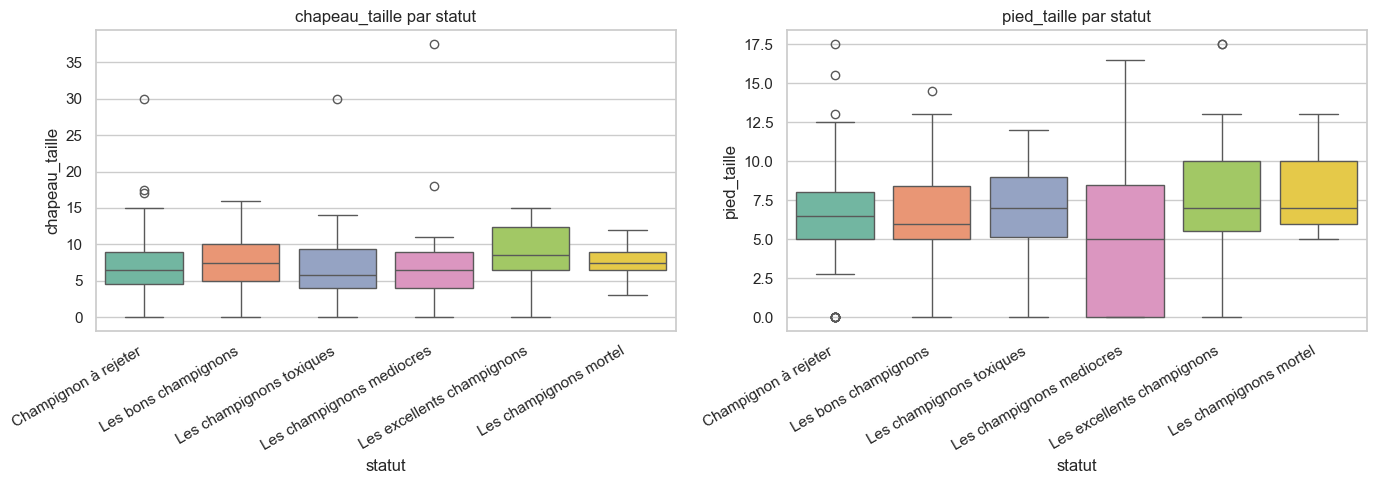

chapeau_taille              pied_taille         \
                                     mean median   std        mean median   
statut                                                                      
Champignon à rejeter                 6.88   6.50  4.59        6.32    6.5   
Les bons champignons                 7.47   7.50  3.61        6.21    6.0   
Les champignons mediocres            7.17   6.50  6.75        5.25    5.0   
Les champignons mortel               7.44   7.50  2.48        8.33    7.0   
Les champignons toxiques             7.21   5.75  5.49        6.75    7.0   
Les excellents champignons           8.83   8.50  4.37        8.28    7.0   

                                  
                             std  
statut                            
Champignon à rejeter        3.51  
Les bons champignons        3.47  
Les champignons mediocres   4.67  
Les champignons mortel      3.03  
Les champignons toxiques    3.09  
Les excellents champignons  4.42

In [23]:
# Reconstruction locale au cas où la section 2 n'aurait pas été exécutée
if "chapeau_taille" not in df.columns:
    df["chapeau_taille"] = (df["chapeau_taille_min_cm"] + df["chapeau_taille_max_cm"]) / 2
if "pied_taille" not in df.columns:
    df["pied_taille"]    = (df["pied_taille_min_cm"]    + df["pied_taille_max_cm"])    / 2

order = df["statut"].value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="statut", y="chapeau_taille", order=order, ax=axes[0], palette="Set2")
axes[0].set_title("chapeau_taille par statut")
axes[0].tick_params(axis="x", rotation=30)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha("right")

sns.boxplot(data=df, x="statut", y="pied_taille", order=order, ax=axes[1], palette="Set2")
axes[1].set_title("pied_taille par statut")
axes[1].tick_params(axis="x", rotation=30)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

plt.tight_layout()
plt.show()

df.groupby("statut")[["chapeau_taille", "pied_taille"]].agg(["mean", "median", "std"]).round(2)

### 5.2 Features binaires — heatmap des proportions par statut

Pour chaque feature binaire, on calcule la proportion d'espèces qui la possèdent dans chaque statut. On ne garde que les features dont **la variance inter-statut est la plus élevée** (= les plus discriminantes).

159 features binaires analysées


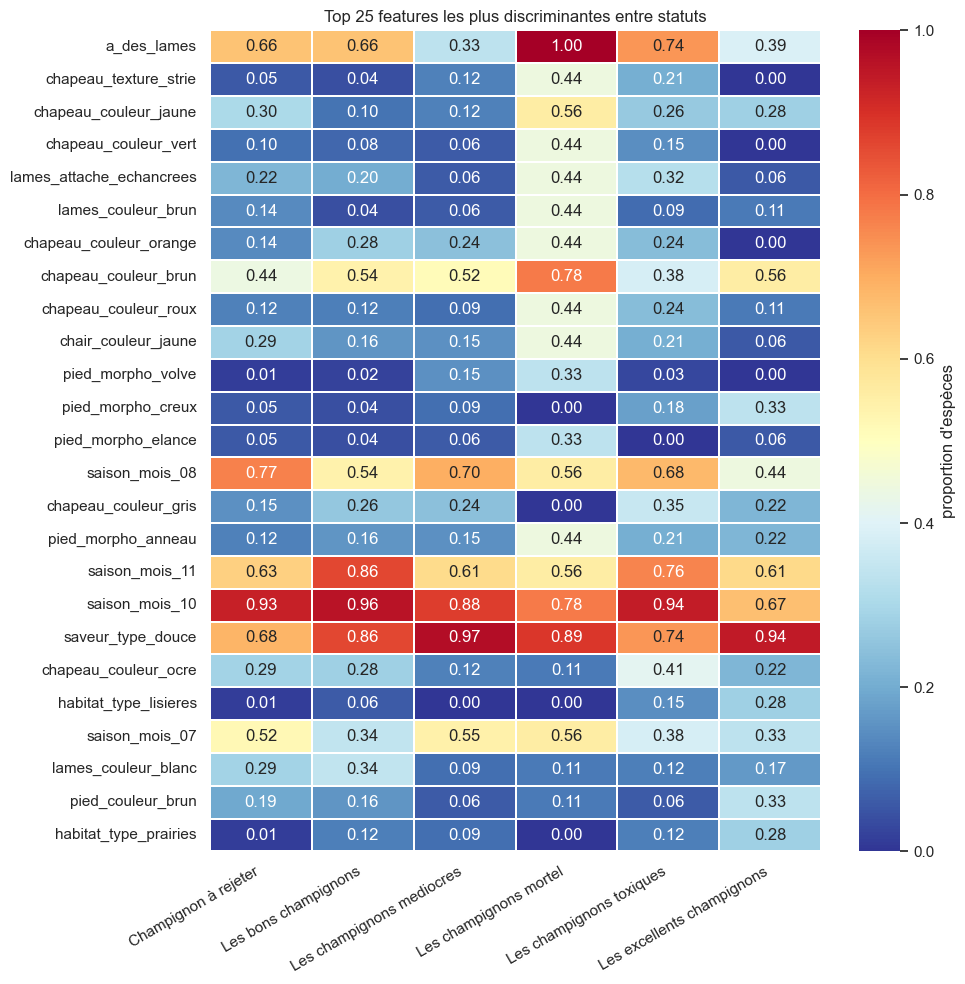

In [24]:
# Sélection automatique des colonnes binaires (0/1) hors tailles, saison, nom, statut
exclude = {"nom", "statut", "chapeau", "pores", "lames", "pied", "chair",
           "odeur", "saveur", "habitat", "saison",
           "chapeau_taille_min_cm", "chapeau_taille_max_cm",
           "pied_taille_min_cm",    "pied_taille_max_cm",
           "chapeau_taille", "pied_taille"}

binary_cols = [
    c for c in df.columns
    if c not in exclude
    and df[c].dtype != object
    and df[c].dropna().isin([0, 1]).all()
]
print(f"{len(binary_cols)} features binaires analysées")

prop_by_statut = df.groupby("statut")[binary_cols].mean()

# Top 25 features les plus discriminantes (variance inter-statut la plus élevée)
top_features = prop_by_statut.var().sort_values(ascending=False).head(25).index
heat = prop_by_statut[top_features].T

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(heat, cmap="RdYlBu_r", annot=True, fmt=".2f",
            cbar_kws={"label": "proportion d'espèces"}, ax=ax, linewidths=0.3)
ax.set_title("Top 25 features les plus discriminantes entre statuts")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 5.3 Corrélation one-vs-rest (point-biserial)

Pour chaque classe de statut, on encode `statut == classe` en binaire et on calcule la corrélation de Pearson avec chaque feature (numérique ou binaire).
- Corrélation **positive** : la feature est sur-représentée dans ce statut.
- Corrélation **négative** : la feature y est sous-représentée.

In [25]:
features = binary_cols + ["chapeau_taille", "pied_taille"]
statut_classes = df["statut"].value_counts().index.tolist()

corr = pd.DataFrame(index=features, columns=statut_classes, dtype=float)
for s in statut_classes:
    target = (df["statut"] == s).astype(int)
    corr[s] = df[features].apply(lambda col: col.corr(target))

corr = corr.fillna(0)
corr.round(3).head(10)

c:\Users\benja\miniconda3\envs\le_panier_sur\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\benja\miniconda3\envs\le_panier_sur\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\benja\miniconda3\envs\le_panier_sur\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\benja\miniconda3\envs\le_panier_sur\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\benja\miniconda3\envs\le_panier_sur\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\benja\miniconda3\envs\le_panier_sur\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarnin

,Champignon à rejeter,Les bons champignons,Les champignons toxiques,Les champignons mediocres,Les excellents champignons,Les champignons mortel
a_un_chapeau,0.002,0.006,0.038,-0.105,0.030,0.063
a_des_pores,-0.030,0.012,-0.077,0.107,0.059,-0.088
a_des_lames,0.065,0.053,0.108,-0.243,-0.138,0.165
a_un_pied,0.014,-0.013,0.025,-0.077,0.021,0.059
a_de_la_chair,-0.033,0.053,-0.091,0.041,0.029,0.020
chapeau_couleur_blanc,-0.095,-0.026,0.055,0.010,0.078,0.054
chapeau_couleur_brun,-0.071,0.056,-0.092,0.023,0.040,0.120
chapeau_couleur_jaune,0.120,-0.169,0.035,-0.110,0.034,0.161
chapeau_couleur_rouge,0.165,0.058,-0.120,-0.046,-0.086,-0.091
chapeau_couleur_orange,-0.116,0.105,0.035,0.042,-0.152,0.125


C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], palette="Greens_r")
C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], palette="Reds")


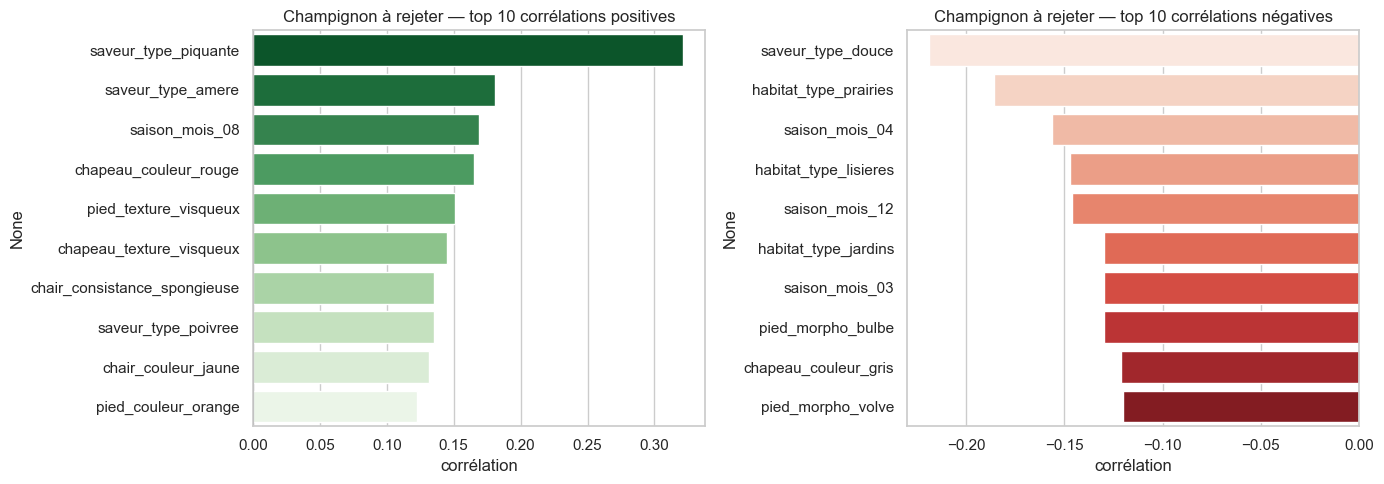

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], palette="Greens_r")
C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], palette="Reds")


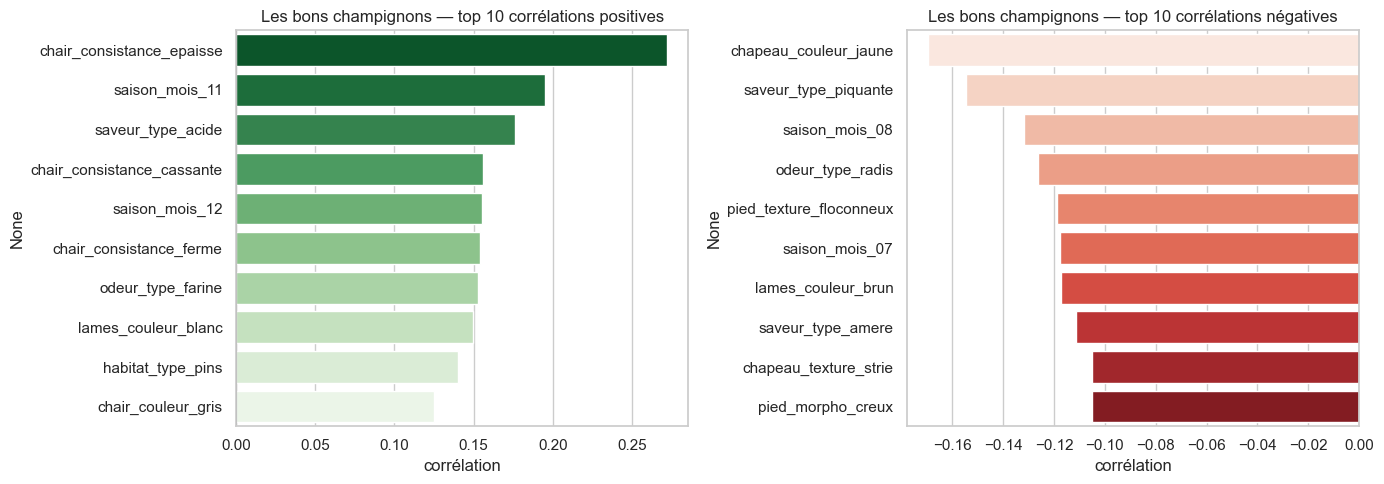

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], palette="Greens_r")
C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], palette="Reds")


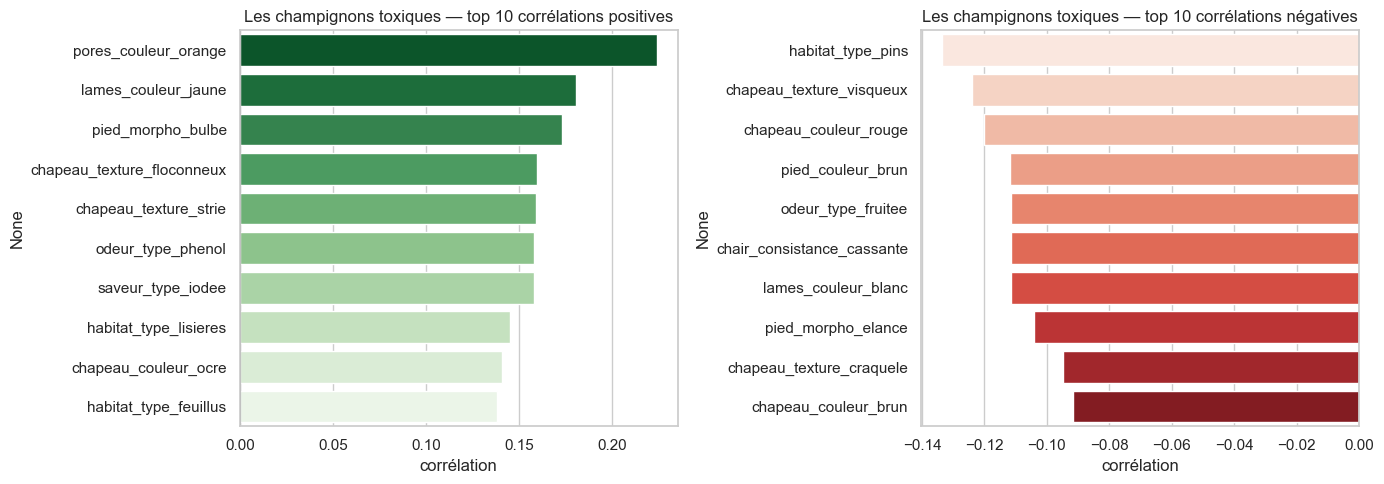

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], palette="Greens_r")
C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], palette="Reds")


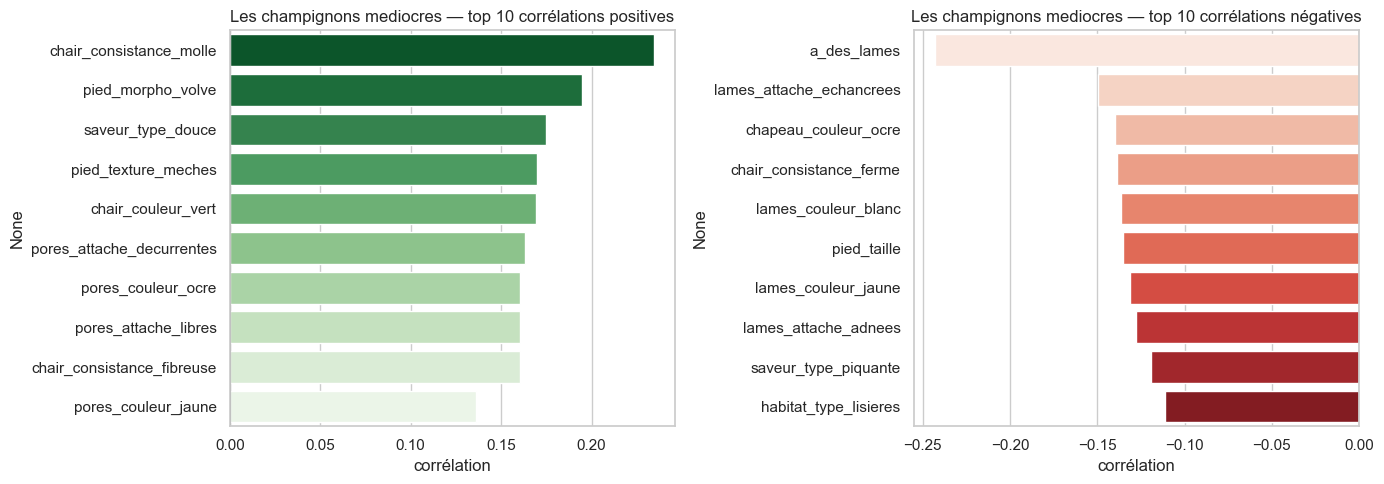

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], palette="Greens_r")
C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], palette="Reds")


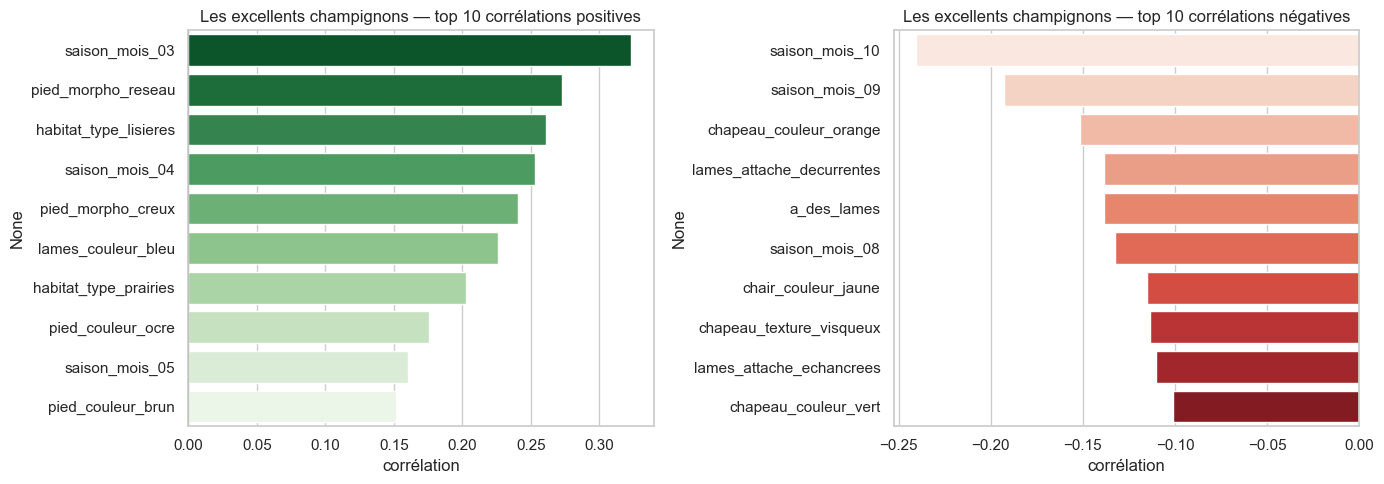

C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], palette="Greens_r")
C:\Users\benja\AppData\Local\Temp\ipykernel_16572\351092481.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], palette="Reds")


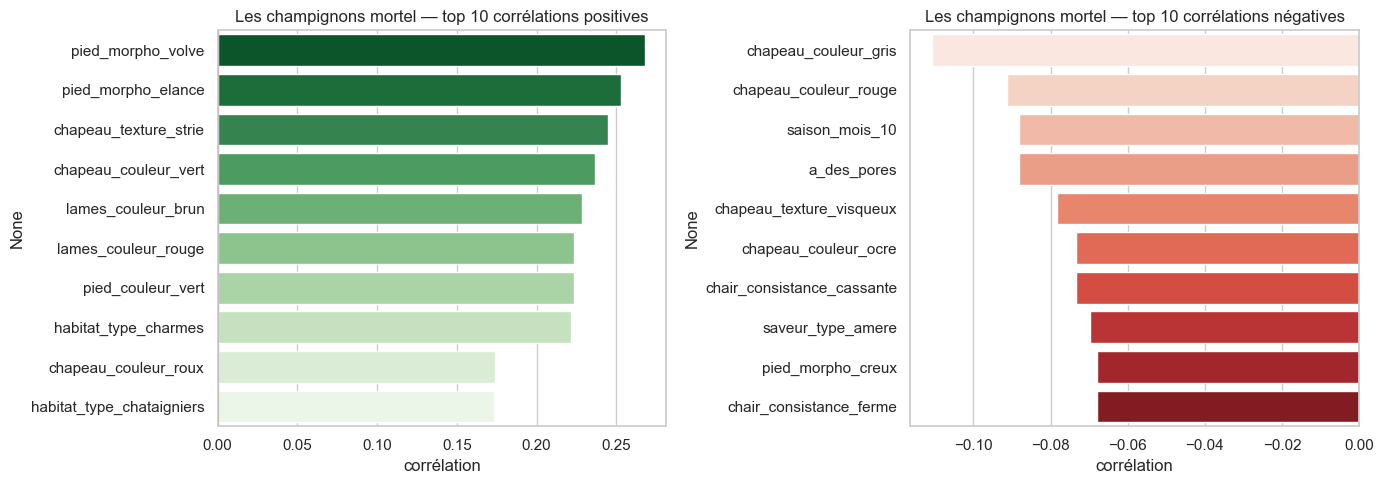

In [26]:
# Top 10 positives et top 10 négatives par classe de statut
for s in statut_classes:
    series = corr[s].sort_values()
    top_pos = series.tail(10).iloc[::-1]
    top_neg = series.head(10)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], palette="Greens_r")
    axes[0].set_title(f"{s} — top 10 corrélations positives")
    axes[0].set_xlabel("corrélation")
    axes[0].axvline(0, color="grey", linewidth=0.8)

    sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], palette="Reds")
    axes[1].set_title(f"{s} — top 10 corrélations négatives")
    axes[1].set_xlabel("corrélation")
    axes[1].axvline(0, color="grey", linewidth=0.8)

    plt.tight_layout()
    plt.show()

### 5.4 Heatmap globale — top features par valeur absolue

Vue consolidée : les features dont la corrélation la plus forte (en valeur absolue, tous statuts confondus) est la plus élevée.

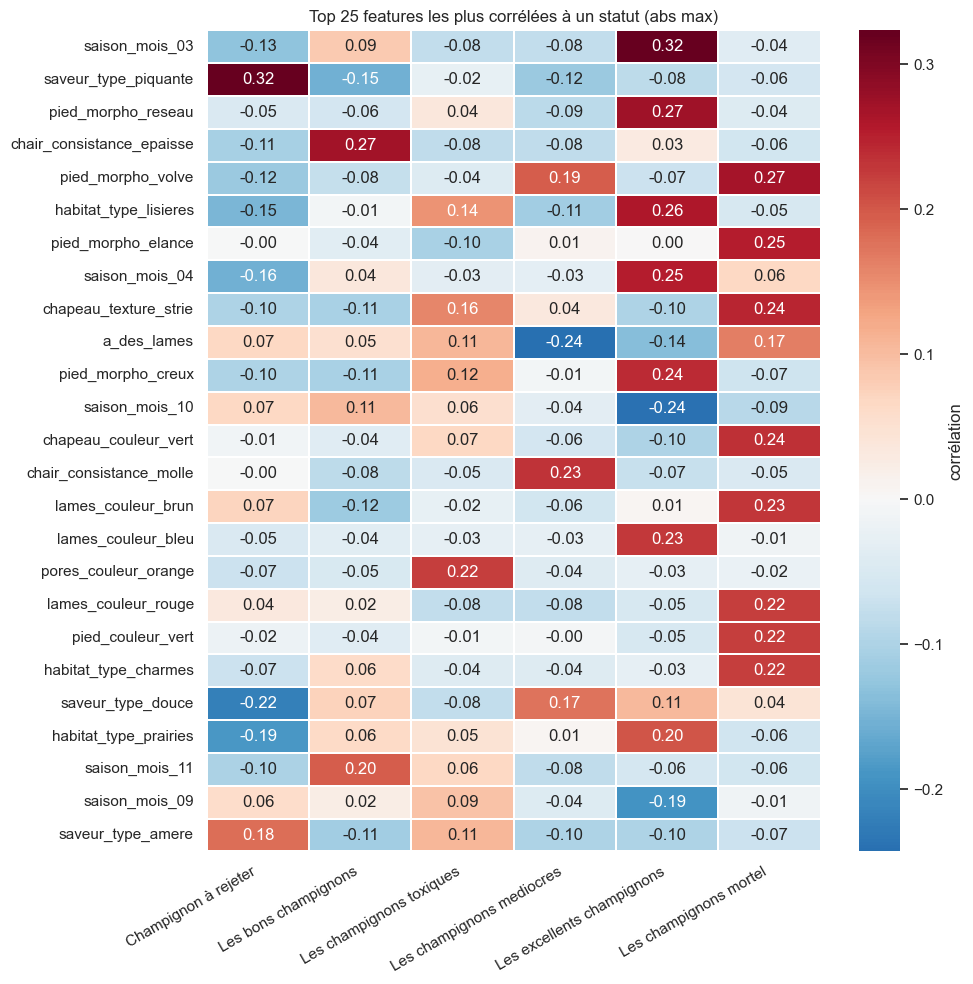

In [27]:
top_abs = corr.abs().max(axis=1).sort_values(ascending=False).head(25).index
heat = corr.loc[top_abs]

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(heat, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "corrélation"}, ax=ax, linewidths=0.3)
ax.set_title("Top 25 features les plus corrélées à un statut (abs max)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()